**Table of contents**<a id='toc0_'></a>    
- [**Objective:** Engineer features and workout the logic for building custom class, to be used as resuable units in preprosessing step.](#toc1_1_1_1_1_)    
      - [About train-test Split:](#toc1_1_1_2_)    
- [**Handling Null Values**](#toc2_)    
  - [Handling Structural Missing Values](#toc2_1_)    
  - [Handling Other Missing Values](#toc2_2_)    
    - [Handling Strategies:](#toc2_2_1_)    
    - [Learning to Build a Custom Imputer (MedianImputer for a single numerical column)](#toc2_2_2_)    
    - [Building and Using Imputers](#toc2_2_3_)    
        - [**NeighborhoodLotFrontageImputer**](#toc2_2_3_1_1_)    
        - [Building MasVnrImputer](#toc2_2_3_1_2_)    
      - [**MasVnrImputer**](#toc2_2_3_2_)    
- [**Feature Engineering**](#toc3_)    
      - [**Feature Engineering Design**](#toc3_1_1_1_)    
      - [**Feature Engineering Design Document**](#toc3_1_1_2_)    
        - [Temporal Features](#toc3_1_1_2_1_)    
        - [Structural Features (Binary values)](#toc3_1_1_2_2_)    
        - [Aggregations](#toc3_1_1_2_3_)    
        - [Ratios](#toc3_1_1_2_4_)    
        - [Interaction Features](#toc3_1_1_2_5_)    
        - [Features Rejected or Later Used](#toc3_1_1_2_6_)    
      - [**Engineer New Features**](#toc3_1_1_3_)    
      - [**Quick Check of Missing Values in Engineered Features**](#toc3_1_1_4_)    
      - [**Judging Engineered Features: New MI Score**](#toc3_1_1_5_)    
      - [**Check For anamoly in GarageAge**](#toc3_1_1_6_)    
        - [Conclusion:](#toc3_1_1_6_1_)    
- [**Final Classification  of Features**](#toc4_)    
      - [Ordinal](#toc4_1_1_1_)    
      - [Nominal](#toc4_1_1_2_)    
      - [Candidate for removal after verification](#toc4_1_1_3_)    
      - [Continuous Numerical](#toc4_1_1_4_)    
      - [Binary / Flag Features](#toc4_1_1_5_)    
      - [Discrete Numerical](#toc4_1_1_6_)    
      - [Elapsed-Time Features](#toc4_1_1_7_)    
      - [Identifier](#toc4_1_1_8_)    
      - [Target](#toc4_1_1_9_)    
- [**Removing Outliers Automatically from Dataset**](#toc5_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

##### <a id='toc1_1_1_1_1_'></a>[**Objective:** Engineer features and workout the logic for building custom class, to be used as resuable units in preprosessing step.](#toc0_)

In [1]:
import pandas as pd 
import numpy as np
import matplotlib as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from pandas.api.types import is_numeric_dtype
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin

sns.set_theme(style="darkgrid")
train_df = pd.read_csv("../data/raw/train.csv")


#### <a id='toc1_1_1_2_'></a>[About train-test Split:](#toc0_)

> **Note:** Train test split would be done directly in train_model.py

* Load the raw train.csv and test.csv datasets

` train_df = pd.read_csv('../data/raw/train.csv')`

` test_df = pd.read_csv('../data/raw/test.csv')`

* Separate target and predictors and remove the SalePrice column from the feature matrix. 

`y =train_df['SalePrice']`

`X = train_df.drop(columns="SalePrice") # Ensures readability`


* Perform a train/validation split on the training data.
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True, stratify=None)

* 42 is a reference to Douglas Adams's The Hitchhiker's Guide to the Galaxy.

* shuffle = True ensures that the training and validation sets are representative of the overall dataset. It randomly picks 20% of rows from anywhere in the dataset (because shuffle=True is the default setting behind the scenes).

- Stratify must be kept none because stratification is designed for categorical classification targets (like predicting 1 or 0) to ensure each fold gets equal class proportions. But SalePrice is a continuous numeric variable (regression target). So it gies an error like: The least populated classes in y have only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2. Classes with too few members are: [34900, 35311, 37900, ...]

- train_test_split attempts to preserve class proportions. Since every SalePrice is effectively unique, each value becomes its own class, making stratification impossible.

- `train_test_split(X, y, test_size=0.2, shuffle=False)`: Takes the bottom 20% of rows sequentially without shuffling.


# <a id='toc2_'></a>[**Handling Null Values**](#toc0_)

## <a id='toc2_1_'></a>[Handling Structural Missing Values](#toc0_)


> **Note**: The handling of structural missingness was done mostly by using the data description so that rules (example NaN means no pool) comes from external knowledge, not from the training distribution. This means this particular transformation is deterministic (i.e. it doesn't estimate anything from the data.) Such transformations does not have a fit stage.

**Deterministic/Rule Based Transformations:**
- Rename columns
- Parse dates
- Replace structural NaNs
- Convert units
- Strip whitespace

**Transformations where Data is Learned:**
- Mean imputation
- Median imputation
- StandardScaler
- PCA
- KNN Imputer
- Target Encoding

In [2]:
# avoid GarageYrBlt, as if we replace missing value in it as 0, it will become outlier.

# Structural features that can have missing values as per the data description. So need to be handled separately, as the null value represents the absence of the feature, and not a missing value.

# Not included MasVnrType, it would be handled in the custom transformer: Exterior1stMasVnrTypeImputer, as trying to put it here, increases the complexity of handling the missing values present in MasVnrType and MAsVnrArea

cat_structural_cols = [
    'Alley', 'BsmtQual', 'BsmtCond', 
    'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 
    'FireplaceQu', 'GarageType', 'GarageFinish', 
    'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 
    'MiscFeature'
]

# It is like asking: "If a parent asset (Basement, Garage, Masonry Veneer) is absent, what numeric measurements must be zero?". that is why we leave other numerical features like Kitchen, Bedroom, TotRmsAbvGrd, Fireplaces, WoodDeckSF, OpenPorchSF, EnclosedPorch, 3SsnPorch, ScreenPorch, PoolArea, MiscVal, 1stFlrSF, 2ndFlrSF, LowQualFinSF etc.

# So even though the training dataset had only a handful out of the below categories having null, I decided to include all related features corresponding to cat_structural_cols list

num_structural_cols = [
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 
    'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 
    'GarageCars', 'GarageArea', 'MasVnrArea', 
    'PoolArea', 'Fireplaces', 'MiscVal'
]
cat_fill_dict = {col: 'None' for col in cat_structural_cols}
num_fill_dict = {col: 0 for col in num_structural_cols} 

structural_fill_dict = {**cat_fill_dict, **num_fill_dict}

train_df = train_df.fillna(value = structural_fill_dict)

print(train_df[cat_structural_cols + num_structural_cols].isnull().sum().sum())


0


In [22]:
null_counts = train_df.isnull().sum()
null_counts[null_counts > 0]

GarageYrBlt    81
dtype: int64

## <a id='toc2_2_'></a>[Handling Other Missing Values](#toc0_)

### <a id='toc2_2_1_'></a>[Handling Strategies:](#toc0_)

**LotFrontage**: Mean is vulnerable to outliers, LotFrontage is right-skewed, so median is a more robust estimator. Training an imputer model is costly, complex, not reproducable. Dropping is not a good option, we may lose a lot of information. Lot frontage depends heavily on neighborhood and zoning. So neighborhood median is intuitive.  
<br>
**Electrical**: As only one row, so we can either drop it or use global mode imputation.  
<br>
**MasVnrType**: Very complicated. Instead of dropping the rows, we can impute MasVnrType using the most common not null veneer type (the Mode) for houses that actually have a veneer. For this we can use the global mode or use the grouping by Exterior1st.  
<br>
**GarageYrBlt**: Engineer new feature: Missing Garage, GarageAge is not good option as 0 will have two different meanings.

### <a id='toc2_2_2_'></a>[Learning to Build a Custom Imputer (MedianImputer for a single numerical column)](#toc0_)

In [ ]:
# from pandas.api.types import is_numeric_dtype
# Custom Imputer: MedianImputer for a single numerical column.

class MedianImputer:
    # Learned class attribute.
    def __init__(self):
        self.median_ = np.nan # The underscore distinguishes learned attributes from constructor parameters.
    def fit(self, X):
        # check whether the incoming Series or array is numeric using pandas.api.types.is_numeric_dtype()
        if not is_numeric_dtype(X):
            raise TypeError(
                "Imputer expects a numeric column"
            )
        self.col_median = X.median()
        return self # for method chaining: MedianImputer().fit(X).transform(X)
    def transform(self, X):
        if self.col_median is None:
            raise ValueError(
                "MedianImputer must be fitted before calling transform()."
            )
        return X.fillna(self.col_median)


**Things I got to know:**
* In scikit-learn, attributes ending with an underscore (like self.col_median_) explicitly signify that the variable was learned during fit() rather than set by the user during initialization

* Scikit-learn transformers expect a 2D array/DataFrame as input

* In Jupyter Notebooks, calling a DataFrame line like X_train.loc[...] without print() only displays if it is the very last line in the cell.

* In Python, DataFrames are passed into functions by reference (they point to the exact same memory location).

* TransformerMixin it automatically writes the fit_transform() method for the class. Else we would have to write: 

`
def fit_transform(self, X, y=None):
   return self.fit(X, y).transform(X)
`
* BaseEstimator connects your custom object to the rest of the scikit-learn ecosystem (like Pipeline, GridSearchCV, and RandomizedSearchCV).

### <a id='toc2_2_3_'></a>[Building and Using Imputers](#toc0_)

In [3]:
#from sklearn.impute import SimpleImputer
electrical_imputer = SimpleImputer(strategy='most_frequent')
electrical_imputer.fit(train_df[["Electrical"]])

train_df['Electrical'] = electrical_imputer.transform(train_df[['Electrical']])[:, 0] # all row, 0th columm
# instead of [:,0] we can use .ravel() also or even .squeeze()

# This feature would be automatically handled by SImpleImputer in the categorical pipeline.


In [4]:
null_counts = train_df.isnull().sum()

null_counts[null_counts > 0]

LotFrontage    259
MasVnrType     872
GarageYrBlt     81
dtype: int64

##### <a id='toc2_2_3_1_1_'></a>[**NeighborhoodLotFrontageImputer**](#toc0_)

In [4]:
#from sklearn.base import BaseEstimator, TransformerMixin

class NeighborhoodLotFrontageImputer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.global_median_ = np.nan # Avoid program crashing during mathematical operation
        self.group_median_ =np.nan # To handle unseen Neighbourhood category

    def fit(self, X):
        # Learn group medians on training data
        self.global_median_ = X['LotFrontage'].median()
        self.group_median_ = X.groupby('Neighborhood')['LotFrontage'].median()
        #print(self.group_median_.head(), end = "\n")
        return self # For chaining
        

    def transform(self, X):
        X = X.copy()
        # Needed AI assistance here:
        mapped_medians = X['Neighborhood'].map(self.group_median_).fillna(self.global_median_)
        #print(mapped_medians.head())
        X['LotFrontage'] = X['LotFrontage'].fillna(mapped_medians)
        return X

lot_imputer = NeighborhoodLotFrontageImputer()
lot_imputer.fit(train_df)
train_df = lot_imputer.transform(train_df)

train_df.loc[train_df['LotFrontage'].isnull()]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice


In [6]:
null_counts = train_df.isnull().sum()

null_counts[null_counts > 0]

MasVnrType     872
GarageYrBlt     81
dtype: int64

##### <a id='toc2_2_3_1_2_'></a>[Building MasVnrImputer](#toc0_)

In [9]:
# train_df.loc[(train_df["MasVnrArea"] == 0) & (train_df["MasVnrType"].notnull()), ["Id", "MasVnrType", "MasVnrArea"]]
train_df.loc[(train_df["MasVnrArea"] > 0) & (train_df["MasVnrType"].isna()), ["Id", "MasVnrType", "MasVnrArea"]]

,Id,MasVnrType,MasVnrArea
624,625,NaN,288.0
773,774,NaN,1.0
1230,1231,NaN,1.0
1300,1301,NaN,344.0
1334,1335,NaN,312.0


In [10]:
train_df.loc[(train_df["MasVnrArea"] == 0) & (train_df["MasVnrType"].notna()), ["Id", "MasVnrType", "MasVnrArea"]]

,Id,MasVnrType,MasVnrArea
688,689,BrkFace,0.0
1241,1242,Stone,0.0


In [11]:
def get_first_mode(series):
    modes = series.mode()
    if not modes.empty:
        return modes[0]
    return None

class Exterior1stMasVnrTypeImputer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.global_mode_ = None
        self.group_mode_ = None

    def fit(self, X):
        # Global mode among homes that actually have veneer
        veneer_homes = X[X['MasVnrArea'] > 0]

        if not veneer_homes['MasVnrType'].dropna().empty:
            self.global_mode_ = veneer_homes["MasVnrType"].mode()[0]
        

        self.group_mode_ = veneer_homes.groupby('Exterior1st')['MasVnrType'].apply(get_first_mode)

        return self

    def transform(self, X):
        X = X.copy()

        mapped_mode = X['Exterior1st'].map(self.group_mode_).fillna(self.global_mode_) # fillna handles unknown categories during production

        X.loc[(X['MasVnrArea'] > 0), 'MasVnrType'] = X.loc[(X['MasVnrArea'] > 0), 'MasVnrType'].fillna(mapped_mode)
        
        return X

masvnrtype_imputer = Exterior1stMasVnrTypeImputer()
masvnrtype_imputer.fit(train_df)

train_df = masvnrtype_imputer.transform(train_df)
    

In [12]:
null_counts = train_df.isnull().sum()

null_counts[null_counts > 0]

GarageYrBlt    81
dtype: int64

In [13]:
# train_df.loc[(train_df["MasVnrArea"] == 0) & (train_df["MasVnrType"].notnull()), ["Id", "MasVnrType", "MasVnrArea"]]
train_df.loc[(train_df["MasVnrArea"] > 0) & (train_df["MasVnrType"].isna()), ["Id", "MasVnrType", "MasVnrArea"]]

,Id,MasVnrType,MasVnrArea


In [15]:
train_df.loc[(train_df["MasVnrArea"] == 0) & (train_df["MasVnrType"] != "None"), ["Id", "MasVnrType", "MasVnrArea"]]

,Id,MasVnrType,MasVnrArea
688,689,BrkFace,0.0
1241,1242,Stone,0.0


> **Note**: How to handle the above case? I think we must go back to the place where the data was collected to clear the ambuigity. Here for ease I am replacing the MAsVnrType as NaN.

In [23]:
class MasVnrImputer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
    def fit(self, X):
        self.masvnrtype_imputer = Exterior1stMasVnrTypeImputer()
        self.masvnrtype_imputer.fit(X)
        return self
    def transform(self, X):
        X = self.masvnrtype_imputer.transform(X)
        X["MasVnrType"] = X["MasVnrType"].fillna('None')
        X.loc[(train_df['MasVnrArea'] == 0), 'MasVnrType'] = 'None'
        return X


# This Custom imputer is merged with the Exterior1stMasVnrTypeImputer, cleaned using AI and put in src/features/preprocessing.py

#### <a id='toc2_2_3_2_'></a>[**MasVnrImputer**](#toc0_)

In [5]:
def get_first_mode(series):
    modes = series.mode()
    if not modes.empty:
        return modes[0]
    return None

class MasVnrImputer(BaseEstimator, TransformerMixin):

    def __init__(self):
        self.global_mode_ = None
        self.group_mode_ = None

    def fit(self, X, y=None):

        veneer_homes = X[X["MasVnrArea"] > 0]

        # Global mode among homes that actually have veneer
        if not veneer_homes["MasVnrType"].dropna().empty:
            self.global_mode_ = veneer_homes["MasVnrType"].mode()[0]

        # Exterior1st-specific mode
        self.group_mode_ = (
            veneer_homes
            .groupby("Exterior1st")["MasVnrType"]
            .apply(get_first_mode)
        )

        return self

    def transform(self, X):

        X = X.copy()

        veneer_mask = X["MasVnrArea"] > 0
        no_veneer_mask = X["MasVnrArea"] == 0

        # Exterior-specific mode → global mode fallback
        mapped_mode = (
            X["Exterior1st"]
            .map(self.group_mode_)
            .fillna(self.global_mode_)
        )

        # Case 1:
        # House has veneer but MasVnrType is missing
        X.loc[veneer_mask, "MasVnrType"] = (
            X.loc[veneer_mask, "MasVnrType"]
            .fillna(mapped_mode.loc[veneer_mask])
        )

        # Case 2:
        # House has no veneer → MasVnrType must be None
        X.loc[no_veneer_mask, "MasVnrType"] = "None"

        # Case 3:
        # Any remaining missing values
        X["MasVnrType"] = X["MasVnrType"].fillna("None")

        return X



masvnrtype_imputer = MasVnrImputer()
masvnrtype_imputer.fit(train_df)

train_df = masvnrtype_imputer.transform(train_df)

In [14]:
train_df.loc[(train_df["MasVnrArea"] == 0) & (train_df["MasVnrType"] != 'None'), ["Id", "MasVnrType", "MasVnrArea"]]

,Id,MasVnrType,MasVnrArea


In [12]:
train_df.loc[(train_df["MasVnrArea"] > 0) & (train_df["MasVnrType"].isna()), ["Id", "MasVnrType", "MasVnrArea"]]

,Id,MasVnrType,MasVnrArea


In [13]:
null_counts = train_df.isnull().sum()

null_counts[null_counts > 0]

GarageYrBlt    81
dtype: int64

# <a id='toc3_'></a>[**Feature Engineering**](#toc0_)

Tree models can learn to approximate almost any combination of features, but when a combination is especially important they can still benefit from having it explicitly created, especially when data is limited.
Counts are especially helpful for tree models, since these models don't have a natural way of aggregating information across many features at once.

In [15]:
with pd.option_context('display.max.columns', None):
    display(train_df.head())

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,None,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,None,None,None,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,None,None,None,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,None,None,None,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,None,None,None,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,None,None,None,0,12,2008,WD,Normal,250000


#### <a id='toc3_1_1_1_'></a>[**Feature Engineering Design**](#toc0_)




| New Feature       | Formula                                | Why?                                              | Keep Original? | Will this feature still make sense on unseen future data?| Does it encode a concept a model can naturally learn? | Is this information already present elsewhere? | Could this introduce ambiguity? |
| ----------------- | -------------------------------------- | ------------------------------------------------- | -------------- | --- | --- | --- | --- |
| HouseAge          | `YrSold - YearBuilt`                   | Easier for models to interpret than absolute year | No             | Yes | Yes | No | No |
| GarageAge         | `YrSold - GarageYrBlt`                 | Represents garage age                             | No             | Yes | Yes | No | Yes, the garage may be absent |
| HasGarage         | `GarageType != "None"`                 | Separates absence from age                        | Yes            | Yes | Yes | No | No |
| YearsSinceRemodel | `YrSold - YearRemodAdd`                | Recency of renovation                             | No             | Yes | Yes | No | Yes if never remodelled |
| Remodeled         | `YearBuilt != YearRemodAdd`            | Whether renovation occurred                       | No             | Yes | Yes | No | Yes if never remodelled | 
|YearsUntilFirstRemodel| `YearRemodAdd - YearBuilt`          | Time until first remodelling                      | No             | Yes | Yes | Perhaps Yes, may cause redundancy  | Yes if never remodelled | 
| TotalBathrooms| `BsmtFullBath + (0.5 * BsmtHalfBath) + FullBath + (0.5 * HalfBath)` | Total bathroooms in whole house, HalfBath have less value than FullBath | Yes | Yes | Yes | No | No |
| TotalPorch | `OpenPorchSF + EnclosedPorch + 3SsnPorch + ScreenPorch + WoodDeckSF` | Total outdoor living area available | Yes | Yes | Yes | No | No |
| TotalUsableSF | `TotalBsmtSF + GrLivArea` | Total usable living area | Yes | Perhaps No | Yes | No | No |
| OverallScore | `OverallQual * OverallCond` | A house with high overall quality of material used but low overall condition may decrease the house value | Yes | Yes | Yes | No | No |
| BsmtFinishedRatio | `(BsmtFinSF1 + BsmtFinSF2)/ TotalBsmtSF` | Directly tells total useable Basement area | Yes | Yes | Yes | No | Maybe no if the house does not have basement | 
| OverallQual_x_TotalSF | `OverallQual * TotalSF` | Indicate Luxuory with size | Yes | Yes | Yes | No | No |
| AvgRoomSize | `GrLivArea/TotRmsAbvGrd` | Average room size above ground | Yes | Yes | Yes | No | Perhaps if the house only has basement | 
| TotalRoomsIncludingBathrooms | `TotRmsAbvGrd + FullBath + HalfBath` |  Indicates total number of rooms including bathroom | Yes | Yes | Yes | Yes, this can be redundant information | No | 
| PrimaryAmenityScore | `(CentralAir == 'Y') + HasGarage + (Fireplaces > 0) + (PoolQC != 'None') + (Utilities = 'AllPub) + (BsmtQual != 'None') + (Heating != 'None') + (Fence != 'None')` | Essential eminities provided |  Yes | Yes | Yes | No | No |  
| Lot_Accessability | `Combination of Street, Alley, PavedDrive ` | Indicate the house accessibility through roads, but i am not sure of appropriate formula | Yes | Yes | Yes | No | No |  




#### <a id='toc3_1_1_2_'></a>[**Feature Engineering Design Document**](#toc0_)

##### <a id='toc3_1_1_2_1_'></a>[Temporal Features](#toc0_)
- HouseAge, drop YearBuilt
- GarageAge
- YearsSinceRemodel

##### <a id='toc3_1_1_2_2_'></a>[Structural Features (Binary values)](#toc0_)
- HasGarage
- Remodeled (Perhaps)

##### <a id='toc3_1_1_2_3_'></a>[Aggregations](#toc0_)
- TotalBathrooms
- TotalUsableSF 
- TotalPorch (Perhaps)

##### <a id='toc3_1_1_2_4_'></a>[Ratios](#toc0_)
- AvgRoomSize (Perhaps)
- BsmtFinishedRatio 

##### <a id='toc3_1_1_2_5_'></a>[Interaction Features](#toc0_)
- OverallScore (Perhaps)
- OverallQual × TotalSF

##### <a id='toc3_1_1_2_6_'></a>[Features Rejected or Later Used](#toc0_)
- YearsUntilFirstRemodel (Many house with same time say 10 does not give useful information.)
- TotalRoomsIncludingBathrooms (Redundant information)
- PrimaryAmenityScore (Perhaps, because many people have different notion of good amenity, better if we can add weights)
- Lot_Accessibility (Great but complicated implementation)

#### <a id='toc3_1_1_3_'></a>[**Engineer New Features**](#toc0_)

In [6]:
train_df['HouseAge'] = train_df['YrSold'] - train_df['YearBuilt']


train_df['GarageAge'] = train_df['YrSold'] - train_df['GarageYrBlt'] # Any Number - NaN = NaN
train_df['GarageAge'] = train_df['GarageAge'].fillna(0) # Double meaning of 0 resolved by HasGarage

train_df['HasGarage'] = (train_df['GarageType'] != "None").astype(int) # We replaced values with "None"


train_df['HasBsmt'] = (train_df['TotalBsmtSF'] > 0).astype(int)


train_df['YearsSinceRemodel'] = train_df['YrSold'] - train_df['YearRemodAdd']



train_df['TotalBathrooms'] = train_df['BsmtFullBath'] + (0.5 * train_df['BsmtHalfBath']) + train_df['FullBath'] + (0.5 * train_df['HalfBath'])



train_df['TotalUsableSF'] = train_df['GrLivArea'] + train_df['TotalBsmtSF']


train_df['BsmtFinishedRatio'] = np.where(
    train_df['TotalBsmtSF'] == 0, 
    0, 
    (train_df['BsmtFinSF1'] + train_df['BsmtFinSF2']) / train_df['TotalBsmtSF']
)



train_df['OverallQual_x_TotalUsableSF'] = train_df['OverallQual'] * train_df['TotalUsableSF']



# train_df = train_df.drop(columns=['YearBuilt', 'GarageYrBlt'])
# We shall drop them using remainder = drop in pipeline
# Got to know new thing: np.where(condition, if_true, if_false)

#### <a id='toc3_1_1_4_'></a>[**Quick Check of Missing Values in Engineered Features**](#toc0_)

In [7]:
new_cols = [
    'HouseAge', 'HasGarage', 'GarageAge', 'YearsSinceRemodel',
    'TotalBathrooms', 'TotalUsableSF', 'BsmtFinishedRatio', 
    'OverallQual_x_TotalUsableSF', 'HasBsmt'
]

# Check for NaNs or Infinite values in newly created columns
print("Missing values in engineered columns:")
print(train_df[new_cols].isnull().sum())

print("\n\nInfinite values in engineered columns:")
print(np.isinf(train_df[new_cols]).sum())

print("\nSample values:")
train_df[new_cols].head()

Missing values in engineered columns:
HouseAge                       0
HasGarage                      0
GarageAge                      0
YearsSinceRemodel              0
TotalBathrooms                 0
TotalUsableSF                  0
BsmtFinishedRatio              0
OverallQual_x_TotalUsableSF    0
HasBsmt                        0
dtype: int64


Infinite values in engineered columns:
HouseAge                       0
HasGarage                      0
GarageAge                      0
YearsSinceRemodel              0
TotalBathrooms                 0
TotalUsableSF                  0
BsmtFinishedRatio              0
OverallQual_x_TotalUsableSF    0
HasBsmt                        0
dtype: int64

Sample values:


,HouseAge,HasGarage,GarageAge,YearsSinceRemodel,TotalBathrooms,TotalUsableSF,BsmtFinishedRatio,OverallQual_x_TotalUsableSF,HasBsmt
0,5,1,5.0,5,3.5,2566,0.824766,17962,1
1,31,1,31.0,31,2.5,2524,0.774960,15144,1
2,7,1,7.0,6,3.5,2706,0.528261,18942,1
3,91,1,8.0,36,2.0,2473,0.285714,17311,1
4,8,1,8.0,8,3.5,3343,0.572052,26744,1


#### <a id='toc3_1_1_5_'></a>[**Judging Engineered Features: New MI Score**](#toc0_)

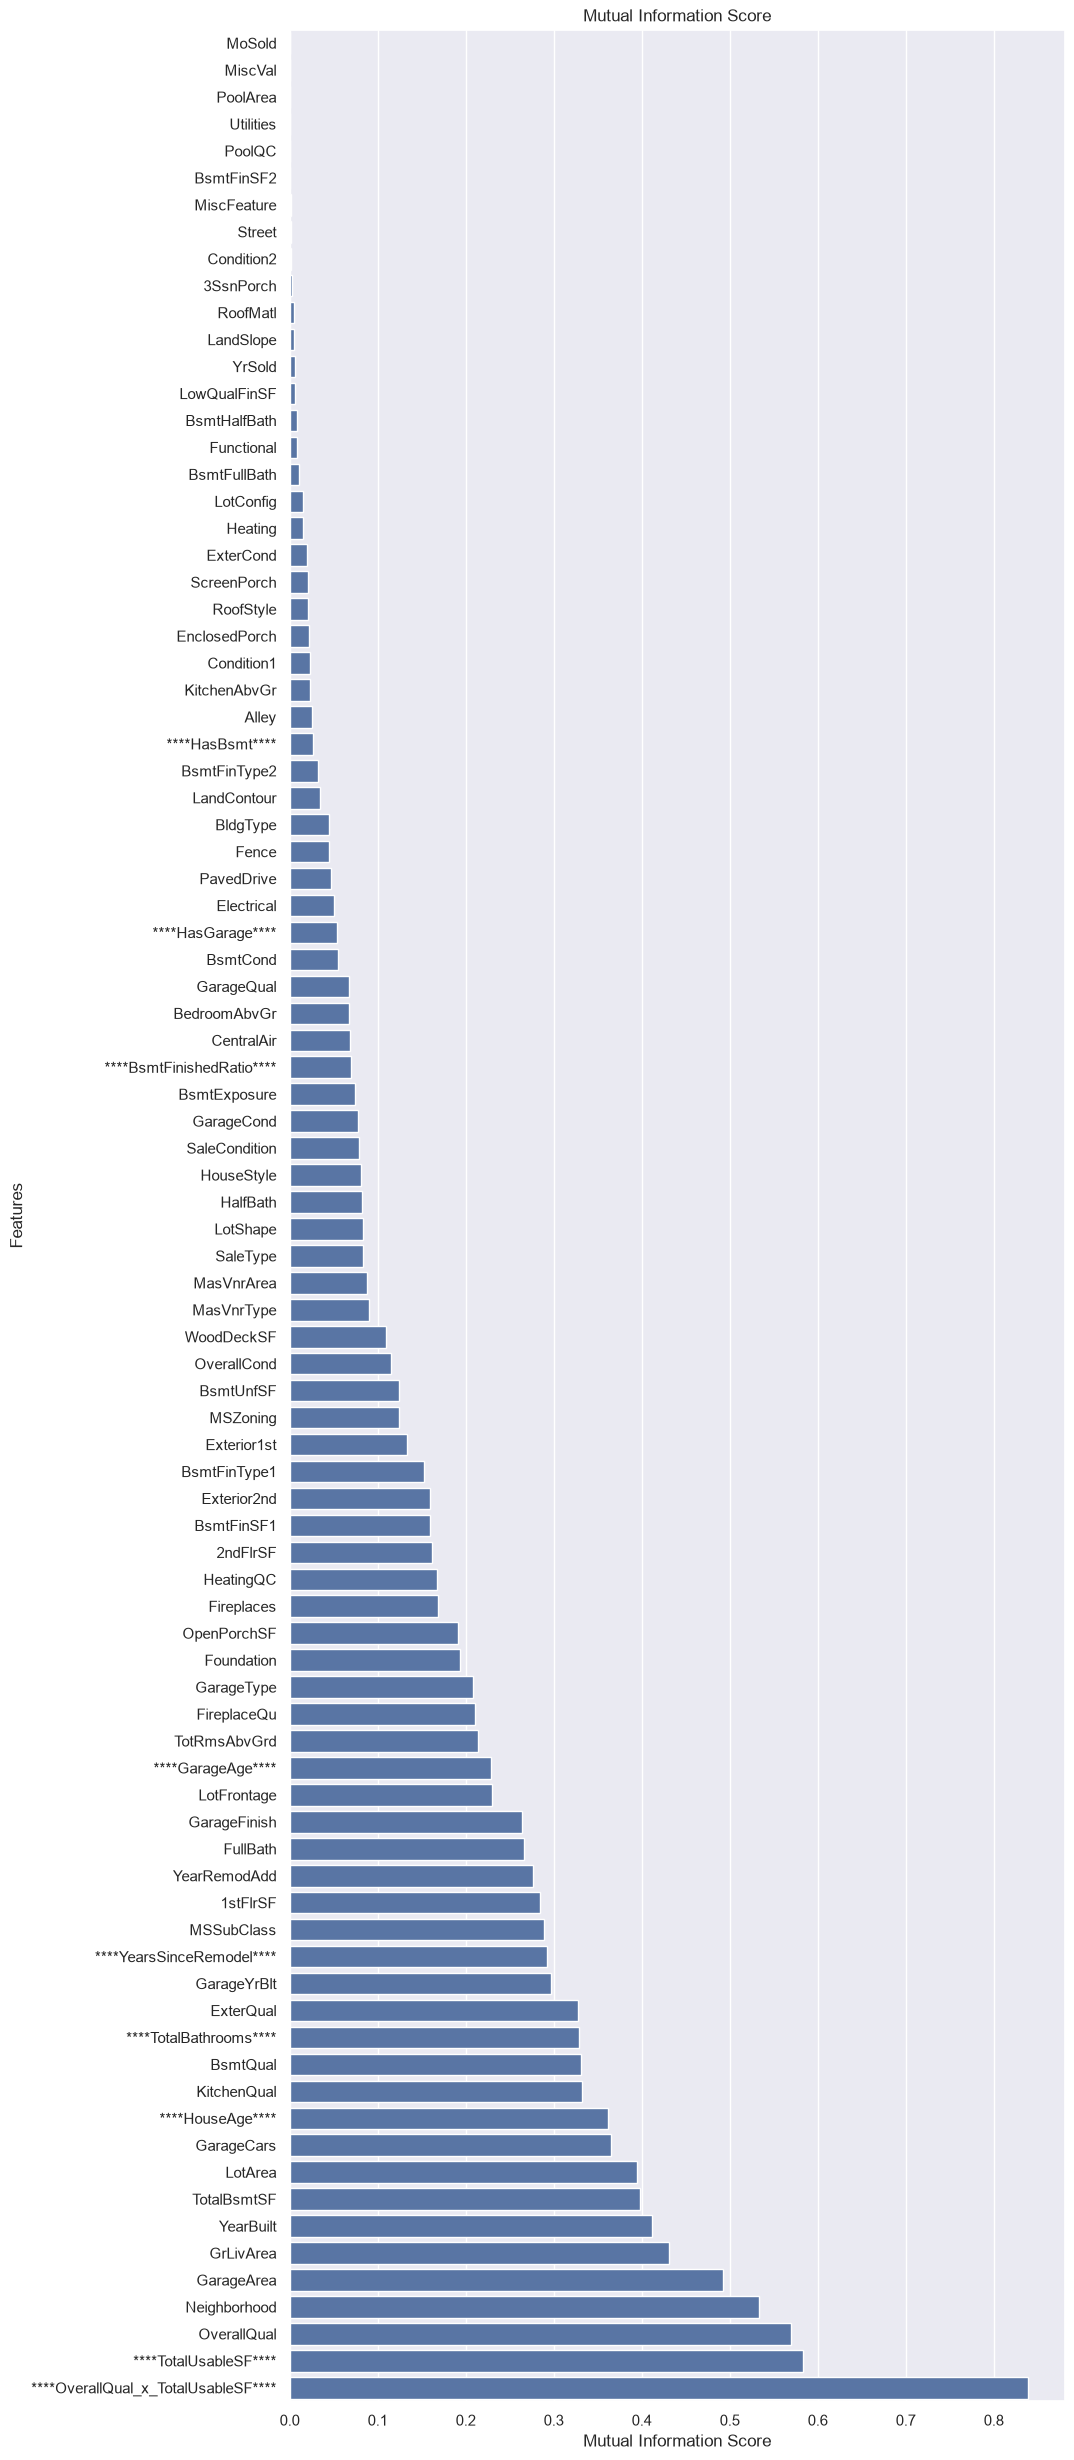

In [9]:
from sklearn.feature_selection import mutual_info_regression


# Make local copies
X = train_df.copy().drop(["Id", "SalePrice"], axis=1)
y = train_df["SalePrice"].copy()


# Label New columns for visual distinction
# Rename specific columns by adding stars
X = X.rename(columns=lambda col: f"****{col}****" if col in new_cols else col)


# Factorize text categories into dummy integers
for colname in X.select_dtypes(include=["object", "string"]): # included string as pandas object backward compatibility
    # pd.factorize handles missing values by assigning them an integer index of -1
    X[colname], _ = X[colname].factorize()



# Fill missing numerical values with column medians: This is already done in this notebook in above lines except GarageYrBlt 
X = X.fillna(X.median())



discrete_features = (X.dtypes == int)



# Calculate mutual information
mi_scores = mutual_info_regression(
    X,
    y,
    discrete_features=discrete_features,
    random_state=42
)

# Create Series
mi_scores = (
    pd.Series(mi_scores, name="MI Scores", index=X.columns)
    .sort_values(ascending=True)
)

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, len(mi_scores) * 0.35))

sns.barplot(
    x=mi_scores.values,
    y=mi_scores.index
)

plt.title("Mutual Information Score")
plt.xlabel("Mutual Information Score")
plt.ylabel("Features")
plt.show()


> Many of the engineered features got top rank in the in the MI score. This tells the effectiveness of the engineered features!

#### <a id='toc3_1_1_6_'></a>[**Check For anamoly in GarageAge**](#toc0_)

<Axes: xlabel='GarageAge', ylabel='Count'>

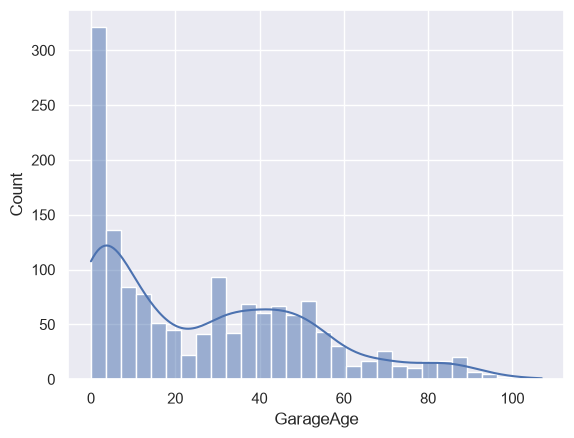

In [10]:
sns.histplot(train_df['GarageAge'], kde=True, bins=30)

##### <a id='toc3_1_1_6_1_'></a>[Conclusion:](#toc0_)

* No anamoly or outlier found.

# <a id='toc4_'></a>[**Final Classification  of Features**](#toc0_)

#### <a id='toc4_1_1_1_'></a>[Ordinal](#toc0_)

* **Columns:** `OverallQual`, `OverallCond`, `ExterQual`, `ExterCond`, `BsmtQual`, `BsmtCond`, `HeatingQC`, `KitchenQual`, `FireplaceQu`, `GarageQual`, `GarageCond`, `PoolQC`, `Fence`, `GarageFinish`, `LotShape`, `LandSlope`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinType2`, `Utilities`, `Functional`, `PavedDrive`
* **Type:** Ordinal
* **Encoding:** Ordinal Encoding (Example: `Ex`=5, `Gd`=4, `TA`=3, `Fa`=2, `Po`=1, `None`=0)
* **Scaling:** I do not think so. (Does ordinal features need scaling, I have never heard of it? Nor read about it in Kaggle.)
* **Keep?** Yes

#### <a id='toc4_1_1_2_'></a>[Nominal](#toc0_)

* **Columns:** `MSZoning`, `Street`, `Alley`, `Neighborhood`, `Condition1`, `BldgType`, `HouseStyle`, `RoofStyle`, `Exterior1st`, `Foundation`, `GarageType`, `SaleType`, `SaleCondition`, `LotConfig`, `LandContour`, `Condition2`, `RoofMatl`, `Exterior2nd`, `MasVnrType`, `Heating`, `Electrical`,  `MiscFeatures`, `MSSubClass`
* **Type:** Nominal
* **Encoding:** One-Hot Encoding
* **Scaling:** No
* **Keep?** Yes 

#### <a id='toc4_1_1_3_'></a>[Candidate for removal after verification](#toc0_)

* **Columns:** `YearBuilt`, `YrSold`, `YearRemodAdd`, `GarageYrBlt`, `GrLivArea`, `TotalBsmtSF`, `1stFlrSF`, `2ndFlrSF`, `FullBath`, `HalfBath`, `BsmtFullBath`, `BsmtHalfBath`
* **Type:** Numerical
* **Encoding:** None
* **Scaling:** N/A
* **Keep?** drop, till now only YearBuilt is dropped. But check the score of model before and after dropping them.

#### <a id='toc4_1_1_4_'></a>[Continuous Numerical](#toc0_)

* **Columns:** `LotFrontage`, `LotArea`, `MasVnrArea`, `BsmtUnfSF`, `GarageArea`, `WoodDeckSF`, `OpenPorchSF`, `EnclosedPorch`, `ScreenPorch`, `3SsnPorch`, `PoolArea`, `MiscVal`, `GrLivArea`, `1stFlrSF`, `2ndFlrSF`, `TotalBsmtSF`, `LowQualFinSF`, `BsmtFinSF1`, `BsmtFinSF2`, `TotalUsableSF` *(Engineered)*, `BsmtFinishedRatio` *(Engineered)*, `OverallQual_x_TotalUsableSF` *(Engineered)*
* **Type:** Continuous Numerical
* **Encoding:** None
* **Scaling:** Yes (StandardScaler / RobustScaler / log-transforms)
* **Keep?** Yes

#### <a id='toc4_1_1_5_'></a>[Binary / Flag Features](#toc0_)

* **Columns:** `CentralAir`, `HasGarage` *(Engineered)*, `HasBsmt` *(Engineered)*
* **Type:** Binary 
* **Encoding:** Binary Map (`Y`=1, `N`=0)
* **Scaling:** No
* **Keep?** Yes

#### <a id='toc4_1_1_6_'></a>[Discrete Numerical](#toc0_)

* **Columns:** `TotalBathrooms` *(Engineered)*, `KitchenAbvGr`, `TotRmsAbvGrd`, `Fireplaces`, `BedroomAbvGr`, `MoSold`, `HalfBath`, `FullBath`, `BsmtFullBath`, `BsmtHalfBath`, `YrSold`, `GarageCars`
* **Type:** Discrete Numerical
* **Encoding:** No
* **Scaling:** Yes (May be)
* **Keep?** Yes 


#### <a id='toc4_1_1_7_'></a>[Elapsed-Time Features](#toc0_)

* **Columns:** `HouseAge` *(Engineered)*, `YearsSinceRemodel` *(Engineered)*, `GarageAge` *(Engineered)*
* **Type:** Discrete Numerical
* **Encoding:** No
* **Scaling:** Yes (Because the values may become large so may need scaling for linear models)
* **Keep?** Yes


#### <a id='toc4_1_1_8_'></a>[Identifier](#toc0_)

* **Columns:** `Id`
* **Type:** Discrete Numerical
* **Encoding:** No
* **Scaling:** No
* **Keep?** No

#### <a id='toc4_1_1_9_'></a>[Target](#toc0_)

* **Columns:** `SalePrice`
* **Type:** Continuous Numerical
* **Encoding:** No
* **Scaling:** No
* **Keep?** No

# <a id='toc5_'></a>[**Removing Outliers Automatically from Dataset**](#toc0_)

Outliers must be dropped/handled before doing the train-test split in the train_model.py script.

> **Note:** The machine learning pipeline assumes it is receiving mathematically valid data. Instead, we can use a schema validation tool (like Pydantic in FastAPI) at the API layer, to check for any data quality violations. Just because we cannot physically hardcode millions of permutations in ML transformers.

In [11]:
train_df.shape

(1460, 90)

In [12]:
class OutlierRemover(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X):
        from sklearn.ensemble import IsolationForest

        
        numerical_df = X.select_dtypes(include=['int64', 'float64'])

        self.iso_ = IsolationForest(contamination=0.01, random_state=42)

        self.preds_ = self.iso_.fit_predict(numerical_df)

        # -1 indicates an outlier, 1 indicates normal data
        self.outliers= X[self.preds_ == -1]

        return self

    def transform(self, X):
        X_new = X.copy()
        X_new = X_new.drop(index=self.outliers.index)
        return X_new

outlier_remover = OutlierRemover()
outlier_remover.fit(train_df)
train_df = outlier_remover.transform(train_df)

train_df.shape

(1445, 90)

* Oops! this may lead to data leakage if i use this on the dataframe that would be split using train-test split.

* The roadmap for script to find outliers automatically, perhaps look like this: load the CSV, perform train_test_split, and then fit the Isolation Forest only on the training split, then drop the outliers from X_train and y_train, and then pass the cleaned data into scikit-learn pipeline.